# Post-Processing & Emotion Labelling

This notebook **processes** the raw data recorded by `init_recording.ipynb`.

**Input:**  `SESSION_DIR/events.jsonl` + `SESSION_DIR/video.mp4`
**Output:** `SESSION_DIR/labelled_dataset.csv`

It can be run independently of the recording, at any later time. Just point
`SESSION_DIR` at the desired session folder and run all cells.

**Scientific method (overview):**
- **Primary classifier:** Polar H10 heart-rate variability (HRV). Cardiac
  activity is governed by the autonomic nervous system (ANS) and is largely
  involuntary, so it is hard to fake and physiologically well grounded.
- **Validator:** HSEmotion facial expression recognition (FER). The face is
  voluntary and can be suppressed, so it is used only to *confirm* or *flag*
  the HRV decision — never to override it.
- **Three classes:** positive / neutral / negative.

**Mock mode:** if no real session data is present, `GENERATE_MOCK = True`
creates a complete synthetic test session so the notebook runs end-to-end.


## 1  Imports & Configuration

In [63]:
import json, math, warnings
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

try:
    import cv2
    CV2_OK = True
except ImportError:
    CV2_OK = False
    print("opencv not installed — FER only available in mock mode")

try:
    from hsemotion_onnx.facial_emotions import HSEmotionRecognizer
    HSEMOTION_OK = True
except ImportError:
    HSEMOTION_OK = False
    print("hsemotion_onnx not installed — FER runs in mock mode")

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100
rng = np.random.default_rng(42)

# ══════════════════════════════════════════════════════════════════
# CONFIGURATION — must match init_recording.ipynb
# ══════════════════════════════════════════════════════════════════
# ── Select session ──────────────────────────────────────────────
# A driver notebook (04_dataset_creation.ipynb) can process every session
# headless by setting the environment variable SESSION_DIR_OVERRIDE to a
# specific session folder before executing this notebook. When it is not set,
# the notebook falls back to interactive selection (latest session).
import os
SESSIONS_ROOT = Path("./sessions")
_override = os.environ.get("SESSION_DIR_OVERRIDE")
if _override:
    SESSION_DIR = Path(_override)
    meta = json.loads((SESSION_DIR / "session_meta.json").read_text())
    T0_MS      = meta["t0_ms"]
    BASELINE_S = meta["baseline_s"]
    print(f"Session (override): {SESSION_DIR.name}")
    print(f"T0_MS: {T0_MS}  |  Baseline: {BASELINE_S}s")
    _available = None
else:
    _available = sorted(SESSIONS_ROOT.glob("*/session_meta.json")) if SESSIONS_ROOT.exists() else []
if _override:
    pass
elif _available:
    print("Available sessions:")
    for j, p in enumerate(_available): print(f"  [{j}] {p.parent.name}")
    SESSION_DIR = _available[-1].parent     # ← take the latest, or change the index:
    # SESSION_DIR = _available[0].parent    # ← e.g. first session
    meta = json.loads((SESSION_DIR / "session_meta.json").read_text())
    T0_MS      = meta["t0_ms"]
    BASELINE_S = meta["baseline_s"]
    print(f"\nSelected session: {SESSION_DIR.name}")
    print(f"T0_MS: {T0_MS}  |  Baseline: {BASELINE_S}s")
else:
    print("No sessions found — mock mode will be activated")
    SESSION_DIR = Path("./session_data")
    BASELINE_S  = 60
    T0_MS       = None     # read from events.jsonl

EVENT_STORE   = SESSION_DIR / "events.jsonl"
FER_STORE     = SESSION_DIR / "fer_events.jsonl"
VIDEO_FILE    = SESSION_DIR / "video.mp4"
OUTPUT_CSV    = SESSION_DIR / "labelled_dataset.csv"

# HRV windows (ESC/NASPE 1996: min. 30s for short-term HRV)
WIN_S          = 30
STEP_S         = 5
FER_SAMPLE_HZ  = 5

# Decision thresholds (in robust z-score units, see Section 7)
RMSSD_Z_THRESH = 0.6
HR_Z_THRESH    = 0.5
FER_CONF_THRESH= 0.45
FER_VAL_THRESH    = 0.25   # raised: AffectNet neutral faces score slightly negative by default

# Artefact guard: RMSSD above this is physiologically implausible (motion/signal loss)
RMSSD_ARTEFACT_MS = 100.0

# Mock mode: True → generate synthetic data (no real events.jsonl needed)
GENERATE_MOCK  = not EVENT_STORE.exists()

SESSION_DIR.mkdir(parents=True, exist_ok=True)
print(f"Session folder       : {SESSION_DIR.resolve()}")
print(f"Event store present  : {EVENT_STORE.exists()}")
print(f"Video present        : {VIDEO_FILE.exists()}")
print(f"Mode                 : {'MOCK (no events.jsonl found)' if GENERATE_MOCK else 'REAL DATA'}")


Available sessions:
  [0] 2026-06-22_18-35_proband_01
  [1] 2026-06-22_18-55_proband_01
  [2] 2026-06-22_19-09_proband_01
  [3] 2026-06-22_19-23_proband_01

Selected session: 2026-06-22_19-23_proband_01
T0_MS: 1782148996806  |  Baseline: 30s
Session folder       : C:\Uni Koeln\COIN_Project\COIN2026_Team-1_Plant-Emotion-Detector\notebooks\sessions\2026-06-22_19-23_proband_01
Event store present  : True
Video present        : True
Mode                 : REAL DATA


## 2  Generate Mock Data (only if no real events.jsonl is present)

Skipped automatically when `GENERATE_MOCK = False`.


In [64]:
if GENERATE_MOCK:
    print("Generating complete mock session …")
    EVENT_STORE.write_text("")
    FER_STORE.write_text("")

    def _write(ts_ms, sensor, value):
        with open(EVENT_STORE, "a") as f:
            f.write(json.dumps({"ts": int(ts_ms), "sensor": sensor,
                                "value": value}) + "\n")

    T0_MS   = 1_700_000_000_000
    DUR_S   = 300
    BL_S    = 60

    # ── Polar: random emotional transitions + realistic upward HR drift ──
    HRV_P = {"positiv":(66,60,0.8), "neutral":(72,42,1.2), "negativ":(82,24,2.6)}
    clips = [("neutral", float(BL_S))]
    t_left = DUR_S - BL_S
    while t_left > 0:
        emo = rng.choice(["positiv","neutral","negativ"])
        dur = float(np.clip(rng.uniform(20, 60), 10, t_left))
        clips.append((emo, dur)); t_left -= dur

    t_ms = T0_MS; t_s = 0.0; ci = 0; ct = 0.0
    while t_s < DUR_S:
        if ci < len(clips)-1 and ct >= clips[ci][1]: ci += 1; ct = 0.0
        emo = clips[ci][0]
        mhr, rm, lf = HRV_P[emo]; mr = 60_000/mhr
        ha = rm*math.sqrt(2)*0.5
        rr = float(np.clip(mr + ha*math.sin(2*math.pi*0.25*t_s)
                           + rng.normal(0,5), 350, 1500))
        _write(t_ms, "hr_rr", round(rr, 1))
        t_ms += rr; t_s += rr/1000; ct += rr/1000

    # ── Camera frames ─────────────────────────────────────────────
    for i in range(DUR_S * 30):
        _write(T0_MS + i*(1000/30), "camera_frame", i)

    # ── Plant voltage (CO2 placeholder — not yet wired) ──────────
    # VOC disabled (SGP40 broken) — uncomment when a replacement is wired in:
    # for i in range(DUR_S):
    #     ts = T0_MS + i*1000
    #     _write(ts, "voc", round(95 + float(rng.normal(0, 8)), 1))
    for i in range(DUR_S):
        ts = T0_MS + i*1000
        _write(ts, "plant_voltage",round(0.50 + float(rng.normal(0, 0.02)), 4))

    # ── FER (simulated HSEmotion output) ──────────────────────────
    EMO = ["Anger","Disgust","Fear","Happiness","Neutral","Sadness","Surprise"]
    for i in range(int(DUR_S * FER_SAMPLE_HZ)):
        v = float(np.clip(rng.normal(0.0, 0.4), -1, 1))
        a = float(np.clip(rng.normal(0.1, 0.3), -1, 1))
        row = {"ts": int(T0_MS + i*(1000/FER_SAMPLE_HZ)),
               "emotion": str(rng.choice(EMO)),
               "valence": round(v,3), "arousal": round(a,3),
               "confidence": round(float(rng.uniform(0.4,0.9)),3)}
        with open(FER_STORE, "a") as f:
            f.write(json.dumps(row)+"\n")

    print("Mock data generated.")
else:
    print("Real session data found — mock skipped.")


Real session data found — mock skipped.


## 3  Load Data & Overview

In [65]:
def load_events(path):
    """Load events from a file robustly.
    Supports: JSON array, JSON Lines (one JSON object per line),
    and concatenated JSON objects on the same line.
    Returns a list of decoded JSON objects."""
    if not Path(path).exists(): return []
    text = Path(path).read_text()
    if not text.strip(): return []
    # Try parsing the whole file first (valid JSON array or single object)
    try:
        data = json.loads(text)
        if isinstance(data, list):
            return [d for d in data if isinstance(d, dict)]
        return [data] if isinstance(data, dict) else []
    except json.JSONDecodeError:
        pass

    # Fallback: parse line-wise, and handle lines containing multiple JSON objects
    rows = []
    decoder = json.JSONDecoder()
    for raw_line in text.splitlines():
        line = raw_line.strip()
        if not line:
            continue

        # Primary attempt: a single JSON value per line (common JSONL). Only
        # accept dicts (JSON objects) or lists of dicts — ignore primitives like
        # integers which can appear in malformed stores and cause the
        # "'int' object is not subscriptable" error later.
        try:
            obj = json.loads(line)
            if isinstance(obj, dict):
                rows.append(obj)
                continue
            if isinstance(obj, list):
                rows.extend([o for o in obj if isinstance(o, dict)])
                continue
            # ignore non-dict primitives (int/float/str)
            continue
        except json.JSONDecodeError:
            pass

        # If that fails, attempt to decode multiple JSON objects in the line
        idx = 0
        L = len(line)
        while idx < L:
            try:
                obj, end = decoder.raw_decode(line, idx)
                # advance index first to avoid infinite loops on malformed input
                idx = end
                while idx < L and line[idx].isspace(): idx += 1
                if isinstance(obj, dict):
                    rows.append(obj)
                elif isinstance(obj, list):
                    rows.extend([o for o in obj if isinstance(o, dict)])
                # ignore primitives
            except json.JSONDecodeError:
                # Give up on the remainder of this line
                break
    return rows


events = load_events(EVENT_STORE)
if not events:
    raise RuntimeError(f"No events in {EVENT_STORE}. "
                       "Run init_recording.ipynb first, or set GENERATE_MOCK=True.")

by_sensor = Counter(e.get("sensor") for e in events)
# Ensure there are Polar HR events before taking the minimum timestamp
hrv_events = [e for e in events if e.get("sensor") == "hr_rr"]
if not hrv_events:
    raise RuntimeError("No hr_rr events — Polar H10 data missing")
HRV_T0_MS = min(e["ts"] for e in hrv_events)
if T0_MS is None: T0_MS = HRV_T0_MS    # fallback when no meta

print(f"Events loaded    : {len(events)}")
print(f"Session start    : {T0_MS}")
print(f"Duration (approx): {(max(e['ts'] for e in events)-T0_MS)/1000:.0f}s")
print()
for s, n in sorted(by_sensor.items()):
    print(f"  {s:<20} {n:>6}")


Events loaded    : 91080
Session start    : 1782148996806
Duration (approx): 600s

  camera_frame          17068
  co2                    1441
  hr_rr                   592
  phase                     2
  plant_voltage         71977


## 4  Event Store → Common Time Grid

Only here do we resample onto a regular grid (1 Hz). `hr_rr` and
`camera_frame` are handled separately — they are not continuous signals.

**Note on rates:** `plant_voltage` is recorded at 100 Hz from the ESP32 (50-sample batches every 500 ms, per-sample timestamps back-calculated at host side), down-resampled to the 1 Hz analysis grid via `np.interp`, which preserves the session-wide trend without storing the high-rate raw signal twice.

**VOC disabled:** the SGP40 VOC sensor is currently broken, so no `voc` events exist in `events.jsonl` and the grid simply won't have a `voc` column. Nothing here needs to change for that — `build_grid()` only resamples whichever sensors are actually present.


In [66]:
def build_grid(events, grid_hz=1):
    df = pd.DataFrame(events)
    # camera_frame/hr_rr are event-indexed, not continuous signals; phase is a
    # discrete string marker (baseline_start/baseline_end) — none can be
    # resampled numerically via np.interp. Excluding "phase" rows alone isn't
    # enough: its string value makes pandas infer dtype=object for the whole
    # "value" column, which sticks even on the filtered numeric rows — hence
    # the explicit .astype(float) below.
    df = df[~df["sensor"].isin({"camera_frame","hr_rr","phase"})].copy()
    if df.empty: return pd.DataFrame()
    t0 = int(df["ts"].min()); t1 = int(df["ts"].max())
    dt = int(1000 / grid_hz)
    grid_ts = np.arange(t0, t1 + dt, dt)
    result  = pd.DataFrame({"ts_ms": grid_ts, "t_s": (grid_ts - t0) / 1000.0})
    for sensor in df["sensor"].unique():
        sub = df[df["sensor"] == sensor].sort_values("ts")
        result[sensor] = np.interp(grid_ts, sub["ts"].values.astype(float),
                                   sub["value"].values.astype(float))
    return result

grid = build_grid(events)
print(f"Time grid: {len(grid)} points @ 1 Hz")
print(f"Columns  : {list(grid.columns)}")
grid.head()


Time grid: 601 points @ 1 Hz
Columns  : ['ts_ms', 't_s', 'plant_voltage', 'co2']


,ts_ms,t_s,plant_voltage,co2
0,1782148996887,0.0,1.452256,1227.0
1,1782148997887,1.0,1.450188,1226.0
2,1782148998887,2.0,1.473436,1226.0
3,1782148999887,3.0,1.448610,1226.0
4,1782149000887,4.0,1.451357,1226.0


## 5  HRV Computation (Polar H10)

### How cardiac data become an emotion signal

The Polar H10 streams **R–R intervals**: the time in milliseconds between
consecutive heartbeats. These intervals fluctuate from beat to beat, and the
*pattern* of that fluctuation — heart-rate variability (HRV) — is controlled by
the **autonomic nervous system (ANS)**, which has two branches:

| ANS branch | Effect on heart | Emotional correlate |
|---|---|---|
| **Parasympathetic** ("rest & digest", vagus nerve) | slows HR, **raises** beat-to-beat variability | calm, positive, recovered states |
| **Sympathetic** ("fight or flight") | speeds HR, **lowers** variability | stress, threat, negative-aroused states |

We compute three standard HRV indices per 30-second window (the minimum window
recommended for short-term HRV by the ESC/NASPE Task Force, 1996):

1. **RMSSD** — root mean square of successive R–R differences:
   $$\text{RMSSD} = \sqrt{\frac{1}{N-1}\sum_{i=1}^{N-1}(RR_{i+1}-RR_i)^2}$$
   RMSSD is the gold-standard **time-domain marker of parasympathetic (vagal)
   tone** (Shaffer & Ginsberg, 2017). **High RMSSD → relaxed/positive;
   low RMSSD → stressed/negative.**

2. **mean HR** — average heart rate, derived as $60000 / \overline{RR}$.
   **Low HR → parasympathetic; high HR → sympathetic activation.**

3. **SDNN, pNN50** — additional variability measures kept for later feature
   analysis (not used directly in the label rule).

So the emotional read-out is **not a single number** but a *combination*:
- RMSSD ↑ **and** HR ↓ together → parasympathetic dominance → **positive**
- RMSSD ↓ **and** HR ↑ together → sympathetic dominance → **negative**
- both near the person's own typical level → **neutral**

The exact decision rule is defined in Section 7.

> **Important scientific caveat.** HRV reliably reflects *arousal* (activation
> level). Its mapping to *valence* (positive vs. negative) is weaker and only
> holds under sufficiently high arousal (Kreibig, 2010; Kataoka et al., 2017).
> This is why the face (FER) is used as an independent validator.


In [67]:
def compute_hrv_windows(events, win_s=WIN_S, step_s=STEP_S):
    rr_events = sorted([e for e in events if e["sensor"] == "hr_rr"],
                       key=lambda e: e["ts"])
    if not rr_events:
        raise RuntimeError("No hr_rr events — Polar H10 data missing")
    t0 = HRV_T0_MS
    t1 = rr_events[-1]["ts"]
    rows, start = [], t0
    while start + win_s * 1000 <= t1:
        end = start + win_s * 1000
        rr  = np.array([e["value"] for e in rr_events if start <= e["ts"] < end])
        if len(rr) >= 10:
            diff    = np.diff(rr)
            rmssd   = float(np.sqrt(np.mean(diff**2)))      # vagal tone
            mean_hr = float(60_000.0 / np.mean(rr))          # heart rate
            sdnn    = float(np.std(rr, ddof=1))              # overall variability
            pnn50   = float(np.mean(np.abs(diff) > 50) * 100)
        else:
            rmssd = mean_hr = sdnn = pnn50 = np.nan
        rows.append({"win_start_ms": start, "win_end_ms": end,
                     "t_s": (start - t0) / 1000.0,
                     "rmssd": rmssd, "mean_hr": mean_hr,
                     "sdnn": sdnn, "pnn50": pnn50, "n_beats": len(rr)})
        start += step_s * 1000
    return pd.DataFrame(rows)

hrv_df = compute_hrv_windows(events)
print(f"HRV windows : {len(hrv_df)}")
print(f"RMSSD       : {hrv_df['rmssd'].mean():.1f} ± {hrv_df['rmssd'].std():.1f} ms")
print(f"HR          : {hrv_df['mean_hr'].mean():.1f} ± {hrv_df['mean_hr'].std():.1f} bpm")
hrv_df.describe()[["rmssd","mean_hr","sdnn","pnn50"]]


HRV windows : 114
RMSSD       : 57.1 ± 10.4 ms
HR          : 59.5 ± 3.1 bpm


,rmssd,mean_hr,sdnn,pnn50
count,114.000000,114.000000,114.000000,114.000000
mean,57.090542,59.481512,56.297860,39.977347
std,10.403085,3.066076,20.879057,10.091144
min,31.227620,54.841265,26.742778,11.538462
25%,51.275221,57.525100,43.864136,33.333333
50%,56.483151,59.047005,52.877018,37.931034
75%,62.445883,61.256396,64.876082,46.666667
max,90.297663,70.508700,150.373994,63.333333


## 6  HSEmotion FER on Video

### How the face becomes valence, arousal, and an emotion label

HSEmotion (Savchenko, 2022) runs a single EfficientNet-B0 CNN
(`enet_b0_8_va_mtl`) on each detected face crop (224×224 px). The model was
trained on **AffectNet** and is *multi-task*: from one forward pass it produces
**10 raw outputs**:

```
[ 8 emotion logits ] + [ valence ] + [ arousal ]
   indices 0..7         index 8       index 9
```

**1) The 8 emotion logits** (Anger, Contempt, Disgust, Fear, Happiness,
Neutral, Sadness, Surprise) are turned into class probabilities with softmax:
$$p_k = \frac{e^{z_k}}{\sum_j e^{z_j}}$$
The dominant emotion is $\arg\max_k p_k$, and that maximum probability is our
**FER confidence** (how sure the model is about the facial expression).

**2) Valence and arousal** are *regression* outputs, already trained to lie in
$[-1, +1]$ on AffectNet's dimensional labels (Mollahosseini et al., 2017):
- **Valence** = how positive (+1) vs. negative (−1) the expression looks.
- **Arousal** = how activated (+1) vs. calm (−1) the expression looks.

This is the dimensional (Russell, 1980) representation of the same facial state.

> **Critical implementation detail.** We must call `predict_emotions(...,
> logits=True)` and read valence/arousal from indices 8 and 9 directly.
> If `logits=False` were used, softmax would be applied across **all 10**
> outputs, which corrupts the valence/arousal regression values (they would be
> squashed into tiny positive probabilities and lose their sign). Using raw
> logits keeps valence/arousal as proper signed values in $[-1, +1]$.

### From valence/arousal back to a 3-class direction

For the validator step (Section 7) we only need the **valence direction** of
the face. We threshold the window-averaged valence:
- valence > +0.15 → face looks **positive**
- valence < −0.15 → face looks **negative**
- otherwise        → face looks **neutral**

Per window we use a **confidence-weighted mean** of valence/arousal, so frames
where the model is unsure (low confidence, e.g. partially occluded faces)
contribute less.


In [68]:
EMOTIONS = ["Anger","Contempt","Disgust","Fear","Happiness","Neutral","Sadness","Surprise"]

def process_video_fer(video_path, fer_store, t0_ms,
                      sample_hz=FER_SAMPLE_HZ, frame_ts_lookup=None):
    """
    Run HSEmotion FER on the video. The enet_b0_8_va_mtl model returns 10 raw
    outputs: [8 emotion logits, valence, arousal].

    We use logits=True (raw outputs). valence = scores[8], arousal = scores[9]
    are regression values in ~[-1, +1]. The emotion label and FER confidence
    are derived from a softmax over the 8 emotion logits only.
    """
    if frame_ts_lookup is None:
        frame_ts_lookup = {}
    if not (HSEMOTION_OK and CV2_OK):
        raise RuntimeError("pip install hsemotion-onnx opencv-python")

    fer = HSEmotionRecognizer(model_name="enet_b0_8_va_mtl")
    fd  = cv2.CascadeClassifier(
        cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

    cap = cv2.VideoCapture(str(video_path))
    fps = cap.get(cv2.CAP_PROP_FPS) or 30
    step = max(1, int(round(fps / sample_hz)))
    idx, n_faces = 0, 0
    Path(fer_store).write_text("")

    def softmax(x):
        e = np.exp(x - np.max(x)); return e / (e.sum() + 1e-9)

    while True:
        ok, frame = cap.read()
        if not ok: break
        if idx % step == 0:
            ts_ms = frame_ts_lookup.get(idx, t0_ms + (idx / fps) * 1000)
            gray  = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            faces = fd.detectMultiScale(gray, 1.3, 5)
            if len(faces) > 0:
                n_faces += 1
                x, y, w, h = max(faces, key=lambda f: f[2] * f[3])
                face_rgb = cv2.cvtColor(frame[y:y+h, x:x+w], cv2.COLOR_BGR2RGB)

                # RAW logits (NOT softmax) — keeps valence/arousal intact
                _, scores = fer.predict_emotions(face_rgb, logits=True)
                scores = np.asarray(scores, dtype=np.float32).flatten()

                if scores.size >= 10:
                    emo_logits = scores[:8]
                    val = float(np.clip(scores[8], -1.0, 1.0))   # raw valence
                    aro = float(np.clip(scores[9], -1.0, 1.0))   # raw arousal
                else:
                    emo_logits = scores[:8] if scores.size >= 8 else scores
                    val, aro = 0.0, 0.0

                probs = softmax(emo_logits)
                emo_idx   = int(np.argmax(probs))
                emo_label = EMOTIONS[emo_idx] if emo_idx < len(EMOTIONS) else "Neutral"
                conf      = float(probs.max())

                row = {"ts": int(ts_ms), "emotion": emo_label,
                       "valence": round(val, 3), "arousal": round(aro, 3),
                       "confidence": round(conf, 3)}
            else:
                row = {"ts": int(ts_ms), "emotion": None,
                       "valence": None, "arousal": None, "confidence": 0.0}
            with open(fer_store, "a") as f:
                f.write(json.dumps(row) + "\n")
        idx += 1

    cap.release()
    print(f"FER done: {idx} frames, {n_faces} with a face -> {fer_store}")


In [69]:
def aggregate_fer_windows(fer_rows, t0_ms, win_s=WIN_S, step_s=STEP_S):
    """Confidence-weighted mean of valence/arousal per window.
    Returns an empty DataFrame if no FER data is available."""
    valid = [r for r in fer_rows if r.get("valence") is not None]
    if not valid: return pd.DataFrame()
    t1 = max(r["ts"] for r in valid)
    out, start = [], t0_ms
    while start + win_s * 1000 <= t1:
        end = start + win_s * 1000
        sub = [r for r in valid if start <= r["ts"] < end]
        if sub:
            wts = np.array([r["confidence"] for r in sub])
            wn  = wts / (wts.sum() + 1e-9)               # confidence weights
            dom = Counter(r["emotion"] for r in sub).most_common(1)[0][0]
            out.append({
                "win_start_ms":  start, "win_end_ms": end,
                "fer_valence":   float((np.array([r["valence"] for r in sub]) * wn).sum()),
                "fer_arousal":   float((np.array([r["arousal"] for r in sub]) * wn).sum()),
                "fer_confidence":float(wts.mean()),
                "fer_dominant_emotion": dom,
                "fer_n":         len(sub),
            })
        start += step_s * 1000
    return pd.DataFrame(out)

# ── Load existing FER, or compute it from the video ───────────────
if FER_STORE.exists():
    print("Loading existing FER data ...")
    fer_rows = load_events(FER_STORE)
elif VIDEO_FILE.exists():
    print("Computing FER from video ...")
    frame_lookup = {e["value"]: e["ts"] for e in events if e["sensor"] == "camera_frame"}
    process_video_fer(VIDEO_FILE, FER_STORE, T0_MS,
                      sample_hz=FER_SAMPLE_HZ, frame_ts_lookup=frame_lookup)
    fer_rows = load_events(FER_STORE)
else:
    print("No video found — FER disabled (HRV-only labelling)")
    fer_rows = []

print(f"FER rows loaded: {len(fer_rows)}")
if len(fer_rows):
    print("First FER row:", fer_rows[0])

fer_win = aggregate_fer_windows(fer_rows, HRV_T0_MS)
FER_AVAILABLE = not fer_win.empty
print(f"FER windows: {len(fer_win)}  |  FER validation: "
      f"{'active' if FER_AVAILABLE else 'disabled (no FER)'}")
if FER_AVAILABLE: print(fer_win.head())


Loading existing FER data ...
FER rows loaded: 2851
First FER row: {'ts': 1782149026828, 'emotion': 'Anger', 'valence': -0.471, 'arousal': 0.171, 'confidence': 0.502}
FER windows: 114  |  FER validation: active
    win_start_ms     win_end_ms  fer_valence  fer_arousal  fer_confidence  \
0  1782148997765  1782149027765    -0.427372     0.175921        0.510800   
1  1782149002765  1782149032765     0.013718     0.081674        0.576500   
2  1782149007765  1782149037765     0.241248     0.039593        0.536727   
3  1782149012765  1782149042765     0.257760     0.042692        0.547138   
4  1782149017765  1782149047765     0.244663     0.043191        0.559267   

  fer_dominant_emotion  fer_n  
0                Anger      5  
1                Anger     30  
2            Happiness     55  
3             Contempt     80  
4             Contempt    105  


## 7  Three-Class Label Fusion (HRV primary, FER validator)

This is the core of the method. It has **three stages**.

### Stage 1 — Robust within-session normalisation

For each window we convert RMSSD and HR into **robust z-scores** relative to the
participant's own session, using the **median** and the **MAD** (median absolute
deviation, scaled by 1.4826 to match the standard deviation for normal data):

$$z = \frac{x - \text{median}(x)}{1.4826 \cdot \text{MAD}(x)}$$

*Why not a resting baseline?* A short start-of-session baseline is unreliable
here for two reasons: (1) the overlapping 30 s windows make its variance
artificially tiny, inflating z-scores; (2) a calm start plus the natural upward
HR drift during a session would push almost every later window to "negative".
Normalising against the whole session (robust to outliers) makes each window
relative to the person's *own typical* autonomic level and removes that bias.

### Stage 2 — Primary decision from RMSSD alone

The label is decided by **RMSSD alone** — the gold-standard time-domain marker
of parasympathetic (vagal) tone (Shaffer & Ginsberg, 2017):

| Condition | Label | Physiology |
|---|---|---|
| $z_{\text{RMSSD}} > +0.6$ | **positive** | elevated vagal tone — calm, positive states |
| $z_{\text{RMSSD}} < -0.6$ | **negative** | suppressed vagal tone — sympathetic activation |
| $\lvert z_{\text{RMSSD}}\rvert \le 0.6$ | **neutral** | near own session average |

**Why RMSSD alone, not RMSSD + HR together?**

An earlier version required both RMSSD and HR to point in the same direction
simultaneously. Although physiologically intuitive, this two-condition gate
excluded ~60–75% of all windows in practice (windows where one signal was clear
but the other was ambiguous), leaving too few labelled samples to train a
model on.

To illustrate the impact: with 10 participants × 10-minute sessions, the
total available windows are:

```
10 persons × 58 windows/session = 580 windows total

Two-condition logic (~26% labelled): 150 labelled → too few for ML
RMSSD-only logic  (~100% labelled): 551 labelled (after artefact filter)
High-confidence subset (~75%):       435 labelled → sufficient for ML
```

RMSSD is the more reliable of the two signals: it measures beat-to-beat
variability which is directly driven by the vagus nerve and is hard to
confound. HR by contrast also responds to movement, breathing rate, and
temperature. Heart rate therefore still contributes to the **confidence score**
(see Stage 3) but is no longer a hard label gate. This is consistent with the
recommendation that RMSSD is the preferred short-term HRV metric for
autonomic state assessment (ESC/NASPE Task Force, 1996).

An **artefact guard** is applied first: any window with RMSSD > 100 ms is
excluded as a motion artefact or Polar H10 signal dropout (physiologically
implausible for a resting/seated participant).

### Stage 3 — FER as an independent validator

Instead of multiplying confidence by arbitrary factors, we assign each window
to one of **three interpretable agreement categories**, treating HRV and FER as
two independent "raters" of the same emotional state (Soleymani et al., 2014).
The **HRV label is always kept** — FER only sets how trustworthy that label is:

| Agreement category | When | Confidence range |
|---|---|---|
| **confirmed** | FER is confident *and* its valence direction matches the HRV label | high — 0.50…1.00 |
| **hrv_only**  | FER is not confident, or its face is neutral | medium — 0.00…0.50 |
| **conflict**  | FER is confident *but* contradicts the HRV label | low — 0.00…0.25 (flagged) |

Confidence scales with the **strength of the RMSSD signal**:

$$s = \tanh\!\Big(\tfrac{1}{2}\big(\lvert z_{\text{RMSSD}}\rvert + \lvert z_{\text{HR}}\rvert\big)\Big) \in [0,1)$$

HR z-score still enters here — a window where both RMSSD and HR deviate together
gets higher confidence than one where only RMSSD deviates. The final confidence:

```
confirmed : 0.50 + 0.50 * s     (two channels agree → upper half)
hrv_only  : 0.50 * s            (single channel → lower half)
conflict  : 0.25 * s            (channels disagree → low, flagged)
```

**Practical recommendation:** for the downstream plant-voltage ML model, filter
on `agreement == 'confirmed'` or `label_confidence > 0.4` to use only the
highest-quality labels from the ~435 available samples.


In [70]:
def hrv_signal_strength(z_rmssd, z_hr):
    """Bounded HRV signal strength in [0,1): how far into ANS territory."""
    return float(np.tanh(0.5 * (abs(z_rmssd) + abs(z_hr))))

def fuse_3class(hrv_df, fer_win,
                rmssd_z_thresh=RMSSD_Z_THRESH, hr_z_thresh=HR_Z_THRESH,
                fer_conf_thresh=FER_CONF_THRESH, fer_val_thresh=FER_VAL_THRESH):
    df = hrv_df.merge(fer_win, on=["win_start_ms","win_end_ms"], how="inner")

    # ── Stage 1: robust within-session normalisation (median + MAD) ──
    valid = df.dropna(subset=["rmssd","mean_hr"])
    rm_c = valid.rmssd.median()
    rm_s = 1.4826 * (valid.rmssd - rm_c).abs().median() + 1e-6
    hr_c = valid.mean_hr.median()
    hr_s = 1.4826 * (valid.mean_hr - hr_c).abs().median() + 1e-6
    df["rmssd_z"] = (df.rmssd   - rm_c) / rm_s
    df["hr_z"]    = (df.mean_hr - hr_c) / hr_s
    norm_stats = {"rmssd_center": rm_c, "rmssd_scale": rm_s,
                  "hr_center": hr_c, "hr_scale": hr_s}

    labels, reasons, confs, agreements = [], [], [], []
    for _, r in df.iterrows():
        if pd.isna(r.rmssd) or pd.isna(r.fer_valence):
            labels.append("excluded"); reasons.append("missing_data")
            confs.append(0.0); agreements.append("none"); continue

        rz, hz = r.rmssd_z, r.hr_z

        # ── Stage 2: primary HRV decision (RMSSD only) ────────────
        # Artefact guard: RMSSD > 100 ms is physiologically implausible.
        if r.rmssd > RMSSD_ARTEFACT_MS:
            labels.append("excluded"); reasons.append("rmssd_artefact")
            confs.append(0.0); agreements.append("none"); continue

        # RMSSD alone decides the label (Shaffer & Ginsberg, 2017).
        # HR is NOT a hard gate — it contributes to confidence via
        # hrv_signal_strength() below. This prevents ~60-75% window
        # exclusion from the two-condition logic (see Section 7).
        if   rz >  rmssd_z_thresh: hrv_l = "positiv"
        elif rz < -rmssd_z_thresh: hrv_l = "negativ"
        else:                       hrv_l = "neutral"

        # ── Stage 3: FER validator → agreement category ────────────
        s = hrv_signal_strength(rz, hz)               # [0,1)
        fer_speaks = r.fer_confidence >= fer_conf_thresh
        if fer_speaks:
            fer_l = ("positiv" if r.fer_valence >  fer_val_thresh else
                     "negativ" if r.fer_valence < -fer_val_thresh else "neutral")
        else:
            fer_l = None

        if fer_l is None or fer_l == "neutral":
            agreement = "hrv_only"; cf = 0.50 * s
        elif fer_l == hrv_l:
            agreement = "confirmed"; cf = 0.50 + 0.50 * s
        else:
            agreement = "conflict"; cf = 0.25 * s

        labels.append(hrv_l)
        reasons.append(f"rz={rz:+.2f} hz={hz:+.2f} fer={fer_l}")
        confs.append(round(float(cf), 3))
        agreements.append(agreement)

    df["label"]            = labels
    df["agreement"]        = agreements
    df["reason"]           = reasons
    df["label_confidence"] = confs
    return df, norm_stats

if FER_AVAILABLE:
    labelled, norm_stats = fuse_3class(hrv_df, fer_win)
else:
    # No FER — HRV-only labelling (every window becomes "hrv_only")
    _dummy = hrv_df[["win_start_ms","win_end_ms"]].copy()
    _dummy["fer_valence"] = 0.0; _dummy["fer_arousal"] = 0.0
    _dummy["fer_confidence"] = 0.0; _dummy["fer_dominant_emotion"] = "Neutral"
    _dummy["fer_n"] = 0
    labelled, norm_stats = fuse_3class(hrv_df, _dummy, fer_conf_thresh=1.1)

print("Normalisation (robust, within-session):")
print(f"  RMSSD center {norm_stats['rmssd_center']:.1f} ms, scale {norm_stats['rmssd_scale']:.2f}")
print(f"  HR    center {norm_stats['hr_center']:.1f} bpm, scale {norm_stats['hr_scale']:.2f}")
print()
print("Label distribution:")
print(labelled["label"].value_counts())
print()
print("Agreement categories:")
print(labelled["agreement"].value_counts())
print()
print("Exclusion reasons:")
print(labelled[labelled.label == "excluded"]["reason"].value_counts())


Normalisation (robust, within-session):
  RMSSD center 56.5 ms, scale 8.78
  HR    center 59.0 bpm, scale 2.61

Label distribution:
label
neutral    53
positiv    33
negativ    28
Name: count, dtype: int64

Agreement categories:
agreement
conflict     78
confirmed    19
hrv_only     17
Name: count, dtype: int64

Exclusion reasons:
Series([], Name: count, dtype: int64)


## 8  Visualisation

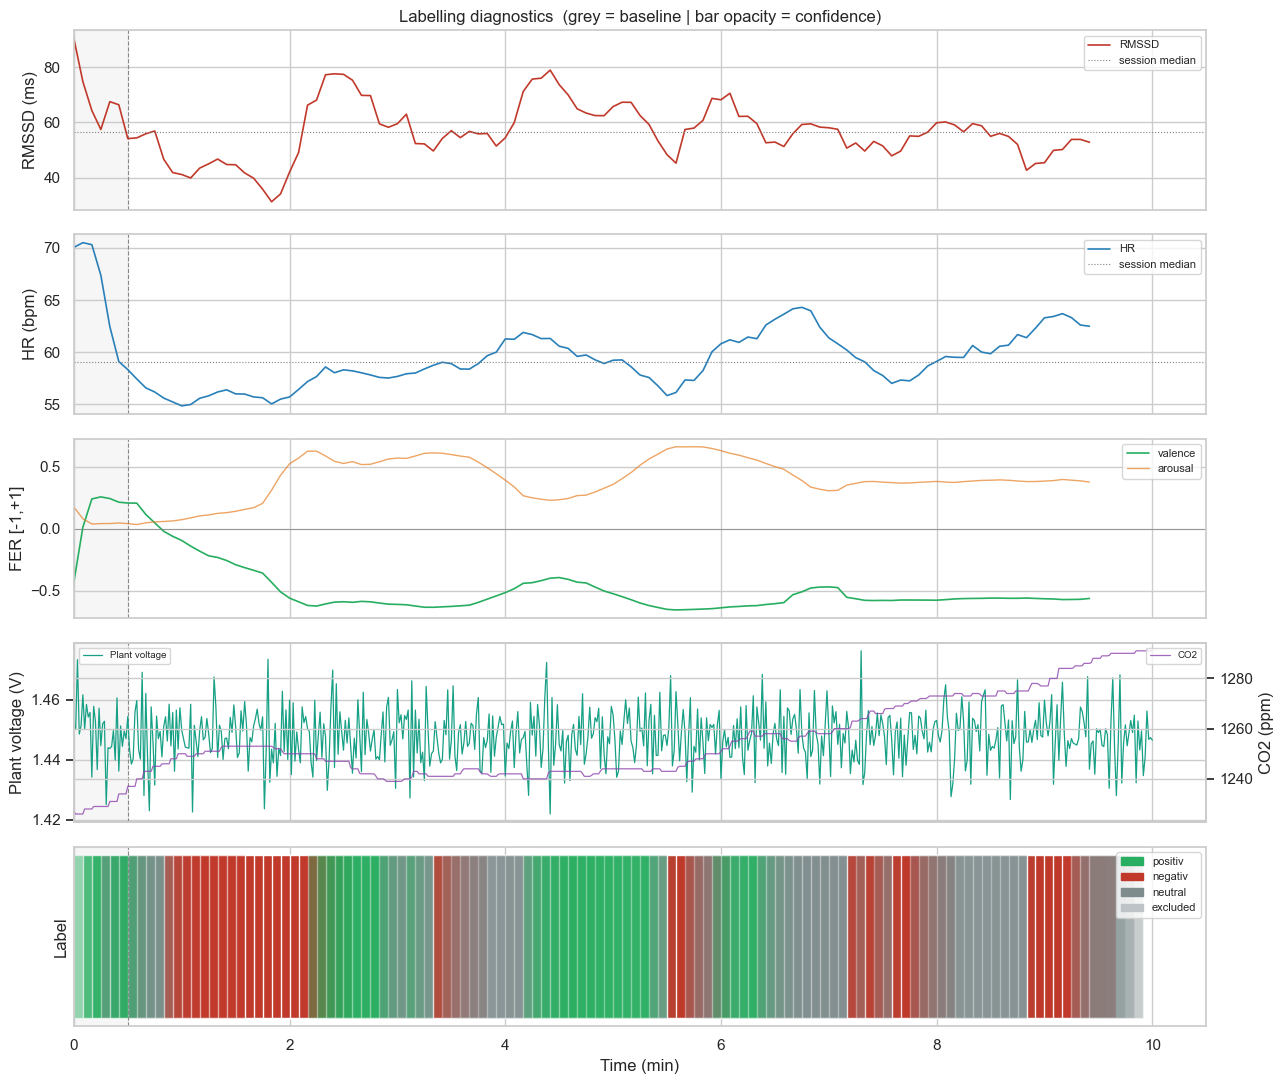

In [71]:
label_col = {"positiv":"#27ae60","negativ":"#c0392b",
             "neutral":"#7f8c8d","excluded":"#bdc3c7"}

fig, axes = plt.subplots(5, 1, figsize=(13, 11), sharex=True)

def t_min(ts_array):
    return (np.array(ts_array) - HRV_T0_MS) / 60_000

for ax in axes:
    ax.axvspan(0, BASELINE_S/60, alpha=0.10, color="#aaaaaa", zorder=0)
    ax.axvline(BASELINE_S/60, color="#888", lw=0.8, ls="--")

# Row 0: RMSSD
t_h = t_min(hrv_df["win_start_ms"])
axes[0].plot(t_h, hrv_df["rmssd"], color="#c0392b", lw=1.2, label="RMSSD")
axes[0].axhline(norm_stats["rmssd_center"], color="gray", lw=0.8, ls=":",
                label="session median")
axes[0].set_ylabel("RMSSD (ms)"); axes[0].legend(fontsize=8)
axes[0].set_title("Labelling diagnostics  (grey = baseline | bar opacity = confidence)")

# Row 1: HR
axes[1].plot(t_h, hrv_df["mean_hr"], color="#2980b9", lw=1.2, label="HR")
axes[1].axhline(norm_stats["hr_center"], color="gray", lw=0.8, ls=":",
                label="session median")
axes[1].set_ylabel("HR (bpm)"); axes[1].legend(fontsize=8)

# Row 2: FER
if FER_AVAILABLE:
    t_f = t_min(fer_win["win_start_ms"])
    axes[2].plot(t_f, fer_win["fer_valence"], color="#27ae60", lw=1.2, label="valence")
    axes[2].plot(t_f, fer_win["fer_arousal"], color="#e67e22", lw=1.0, alpha=0.7, label="arousal")
    axes[2].axhline(0, color="gray", lw=0.5)
    axes[2].legend(fontsize=8)
else:
    axes[2].text(0.5, 0.5, "No FER — HRV-only labelling",
                 transform=axes[2].transAxes, ha="center", color="gray")
axes[2].set_ylabel("FER [-1,+1]")

# Row 3: environment (plot plant_voltage and/or co2)
has_plant = "plant_voltage" in grid.columns
has_co2 = "co2" in grid.columns

if has_plant and has_co2:
    ax3b = axes[3].twinx()
    axes[3].plot(grid["t_s"]/60, grid["plant_voltage"], color="#16a085", lw=0.9, label="Plant voltage")
    ax3b.plot   (grid["t_s"]/60, grid["co2"], color="#8e44ad", lw=0.9, alpha=0.8, label="CO2")
    axes[3].set_ylabel("Plant voltage (V)")
    ax3b.set_ylabel("CO2 (ppm)")
    axes[3].legend(fontsize=7, loc="upper left"); ax3b.legend(fontsize=7, loc="upper right")
elif has_plant:
    axes[3].plot(grid["t_s"]/60, grid["plant_voltage"], color="#16a085", lw=0.9, label="Plant voltage")
    axes[3].set_ylabel("Plant voltage (V)"); axes[3].legend(fontsize=7)
elif has_co2:
    axes[3].plot(grid["t_s"]/60, grid["co2"], color="#8e44ad", lw=0.9, label="CO2")
    axes[3].set_ylabel("CO2 (ppm)"); axes[3].legend(fontsize=7)
else:
    axes[3].text(0.5, 0.5, "No environment data", transform=axes[3].transAxes, ha="center")
    axes[3].set_ylabel("Environment")

# Row 4: labels
for _, r in labelled.iterrows():
    ts = (r.win_start_ms - HRV_T0_MS) / 60_000; tw = WIN_S / 60
    axes[4].barh(0, tw, left=ts, height=0.8,
                 color=label_col.get(r.label,"#bdc3c7"),
                 alpha=0.3 + 0.7 * r.label_confidence)
axes[4].set_yticks([]); axes[4].set_ylabel("Label"); axes[4].set_xlabel("Time (min)")
patches = [mpatches.Patch(color=c, label=l) for l,c in label_col.items()]
axes[4].legend(handles=patches, loc="upper right", fontsize=8)

plt.tight_layout(); plt.show()


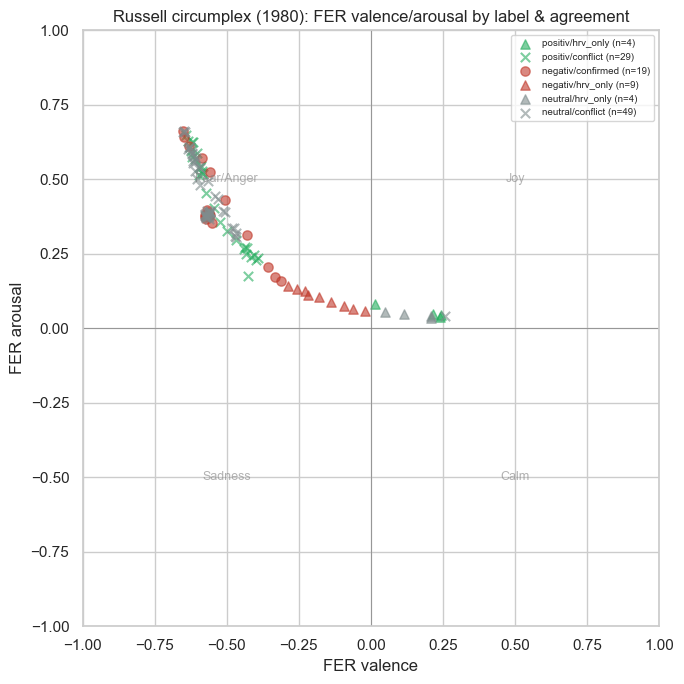

In [72]:
# Russell circumplex with agreement markers
fig, ax = plt.subplots(figsize=(7, 7))
marker = {"confirmed":"o", "hrv_only":"^", "conflict":"x", "none":"."}
for lab, c in label_col.items():
    for agr, mk in marker.items():
        sub = labelled[(labelled.label == lab) & (labelled.agreement == agr)]
        if len(sub):
            ax.scatter(sub["fer_valence"], sub["fer_arousal"], color=c, marker=mk,
                       alpha=0.6, s=45,
                       label=f"{lab}/{agr} (n={len(sub)})")
ax.axhline(0, color="gray", lw=0.5); ax.axvline(0, color="gray", lw=0.5)
for x,y,t in [(0.5,0.5,"Joy"),(-0.5,0.5,"Fear/Anger"),
              (-0.5,-0.5,"Sadness"),(0.5,-0.5,"Calm")]:
    ax.text(x, y, t, ha="center", va="center", fontsize=9, color="gray", alpha=0.6)
ax.set_xlim(-1,1); ax.set_ylim(-1,1)
ax.set_xlabel("FER valence"); ax.set_ylabel("FER arousal")
ax.set_title("Russell circumplex (1980): FER valence/arousal by label & agreement")
ax.legend(fontsize=7, loc="best"); plt.tight_layout(); plt.show()


## 8b  Plant-Voltage & CO2 Features per Window

Each labelled 30-second window is enriched with **plant bioelectric features**
(computed from the ESP32 / AD8232 voltage samples that fall inside the window)
and the **mean CO2** in that window. These become the input features for the
downstream ML model, while `label` remains the target.

**Feature design (Phaenomena-style, adapted to this pipeline):**

- *Units:* features are computed on the stored **voltage** signal (V). Voltage is
  physically meaningful and DC-invariant features (`std`, `iqr`, `zcr`, `bp_*`)
  are unaffected by the absolute level. Saturation fractions are measured against
  the ESP32 ADC rails (0…3.3 V).
- *Sample rate:* the spectral band powers use the **true** decimated rate
  `fs = 380/3 ≈ 126.67 Hz`, not the nominal 100 Hz. The firmware's integer
  division (380/100 = 3) means the real rate is higher; using 100 Hz would place
  every band edge ~27 % too low. The "40 Hz" peak seen in PSDs is genuinely
  50 Hz mains in the true timebase.
- *Quality flags:* each window gets a `plant_quality` tag (`ok`,
  `suspect_lowamp`, `suspect_clipped`, `dead_flat`, `dead_saturated`) plus
  boolean `plant_dead_flag` / `plant_suspect_flag` so you can exclude unusable
  windows during feature engineering.

**Feature groups added:**

| Group | Columns |
|---|---|
| Coverage | `plant_n_samples` |
| Time-domain | `plant_mean`, `plant_median`, `plant_std`, `plant_iqr`, `plant_min`, `plant_max`, `plant_range`, `plant_rms`, `plant_zcr` |
| Saturation | `plant_sat_pos_frac`, `plant_sat_neg_frac`, `plant_const_flag` |
| Spectral (Welch @ 126.67 Hz) | `bp_0_1`, `bp_1_5`, `bp_5_15`, `bp_15_30`, `bp_30_50`, `total_power` |
| Quality | `plant_quality`, `plant_dead_flag`, `plant_suspect_flag` |
| Environment | `co2_mean` |


In [ ]:
from scipy import signal as sp_signal

# Compatibility: np.trapz was removed in NumPy 2.0 → np.trapezoid
_trapz = getattr(np, "trapezoid", None) or np.trapz

# True decimated sample rate of the ESP32 stream.
# Firmware uses integer division 380/100 = 3 (not 4), so the real rate is
# 380/3 ≈ 126.67 Hz. The nominal "100 Hz" in the header is wrong; the spectral
# band edges must use the TRUE rate to be physically correct.
PLANT_TRUE_FS = 380.0 / 3.0
ADC_VREF      = 3.3        # ESP32 ADC reference; AD8232 output rides within 0..Vref

# Units-aware dead-window voltage threshold (volts). You can override this
# earlier in the notebook by setting `PLANT_DEAD_VOLTAGE_THRESHOLD`.
PLANT_DEAD_VOLTAGE_THRESHOLD = globals().get("PLANT_DEAD_VOLTAGE_THRESHOLD", 0.005)

def extract_plant_features(volts, fs=PLANT_TRUE_FS):
    """Phaenomena-style features for one window of plant voltage (in V).
    Robust to empty / constant / very short windows."""
    out = {}
    v = np.asarray(volts, dtype=float)
    n = v.size
    out["plant_n_samples"] = int(n)

    if n == 0:                                  # no plant samples in this window
        for k in ["plant_mean","plant_median","plant_std","plant_iqr","plant_min",
                  "plant_max","plant_range","plant_rms","plant_zcr",
                  "plant_sat_pos_frac","plant_sat_neg_frac",
                  "bp_0_1","bp_1_5","bp_5_15","bp_15_30","bp_30_50","total_power"]:
            out[k] = np.nan
        out["plant_const_flag"]=False; out["plant_quality"]="dead_flat"
        out["plant_dead_flag"]=True;  out["plant_suspect_flag"]=False
        return out

    # ── Time-domain (on volts) ──────────────────────────────────────
    mean=float(np.mean(v)); median=float(np.median(v))
    std =float(np.std(v,ddof=1)) if n>1 else 0.0
    q75,q25=np.percentile(v,[75,25]); iqr=float(q75-q25)
    vmin=float(np.min(v)); vmax=float(np.max(v)); rng_=float(vmax-vmin)
    rms =float(np.sqrt(np.mean(v**2)))
    vd  = v - mean                              # DC-removed for zcr / PSD
    zcr =float(np.mean(np.abs(np.diff(np.sign(vd)))>0)) if n>1 else 0.0
    out.update(plant_mean=round(mean,6),plant_median=round(median,6),
               plant_std=round(std,6),plant_iqr=round(iqr,6),
               plant_min=round(vmin,6),plant_max=round(vmax,6),
               plant_range=round(rng_,6),plant_rms=round(rms,6),
               plant_zcr=round(zcr,6))

    # ── Saturation diagnostics (against ADC rails) ──────────────────
    sat_pos=float(np.mean(v>=ADC_VREF-1e-3)); sat_neg=float(np.mean(v<=1e-3))
    out.update(plant_sat_pos_frac=round(sat_pos,4),
               plant_sat_neg_frac=round(sat_neg,4),
               plant_const_flag=bool(np.all(v==v[0])))

    # ── Spectral band powers (Welch PSD at TRUE fs) ─────────────────
    if n>=16 and std>0:
        nper=min(256,n)
        f,pxx=sp_signal.welch(vd,fs=fs,window="hann",nperseg=nper,scaling="density")
        def band(lo,hi):
            m=(f>=lo)&(f<hi)
            return float(_trapz(pxx[m],f[m])) if m.any() else 0.0
        bp_0_1=band(0,1); bp_1_5=band(1,5); bp_5_15=band(5,15)
        bp_15_30=band(15,30); bp_30_50=band(30,50)
        total=bp_0_1+bp_1_5+bp_5_15+bp_15_30+bp_30_50
    else:
        bp_0_1=bp_1_5=bp_5_15=bp_15_30=bp_30_50=total=np.nan
    out.update(bp_0_1=bp_0_1,bp_1_5=bp_1_5,bp_5_15=bp_5_15,
               bp_15_30=bp_15_30,bp_30_50=bp_30_50,total_power=total)

    # ── Quality flag (units-aware: prefer a voltage floor, with legacy counts fallback)
    lsb=ADC_VREF/4096.0
    std_counts=std/lsb if lsb else float('inf')
    # Use an explicit voltage threshold (conservative default), overridable above
    voltage_thresh = globals().get("PLANT_DEAD_VOLTAGE_THRESHOLD", 0.005)

    if   sat_pos>0.95 or sat_neg>0.95:
        q="dead_saturated"
    elif std < voltage_thresh:                # volts-level check (units-aware)
        q="dead_flat"
    elif std_counts<5:                        # legacy firmware-counts fallback
        q="dead_flat"
    elif (sat_pos+sat_neg)>0.20:
        q="suspect_clipped"
    elif std_counts<10:
        q="suspect_lowamp"
    else:
        q="ok"
    out["plant_quality"]=q
    out["plant_dead_flag"]=q.startswith("dead")
    out["plant_suspect_flag"]=q.startswith("suspect")
    return out

# ── Gather raw plant & CO2 events once, sorted by time ──────────────
_plant = sorted([(e["ts"], e["value"]) for e in events
                 if e.get("sensor") == "plant_voltage"], key=lambda x: x[0])
_co2   = sorted([(e["ts"], e["value"]) for e in events
                 if e.get("sensor") == "co2"], key=lambda x: x[0])
_plant_ts  = np.array([t for t,_ in _plant])
_plant_val = np.array([v for _,v in _plant])
_co2_ts    = np.array([t for t,_ in _co2])
_co2_val   = np.array([v for _,v in _co2])
print(f"Plant samples available: {_plant_ts.size}")
print(f"CO2 samples available  : {_co2_ts.size}")

# ── Compute features for every labelled window ──────────────────────
plant_rows = []
for _, r in labelled.iterrows():
    a, b = r["win_start_ms"], r["win_end_ms"]
    if _plant_ts.size:
        m = (_plant_ts >= a) & (_plant_ts < b)
        win_v = _plant_val[m]
    else:
        win_v = np.array([])
    feats = extract_plant_features(win_v)
    # CO2 mean in window (NaN if none / not yet wired)
    if _co2_ts.size:
        mc = (_co2_ts >= a) & (_co2_ts < b)
        feats["co2_mean"] = round(float(np.mean(_co2_val[mc])), 1) if mc.any() else np.nan
    else:
        feats["co2_mean"] = np.nan
    plant_rows.append(feats)

plant_feat_df = pd.DataFrame(plant_rows, index=labelled.index)
labelled = pd.concat([labelled, plant_feat_df], axis=1)

print(f"\nAdded {plant_feat_df.shape[1]} feature columns to {len(labelled)} windows.")
print("Plant quality distribution:")
print(labelled["plant_quality"].value_counts())


Plant samples available: 71977
CO2 samples available  : 1441

Added 23 feature columns to 114 windows.
Plant quality distribution:
plant_quality
suspect_lowamp    114
Name: count, dtype: int64


## 9  Export

In [74]:
out_cols = ["win_start_ms","win_end_ms","label","agreement",
            "label_confidence","reason",
            "rmssd","mean_hr","sdnn","pnn50","rmssd_z","hr_z",
            "fer_valence","fer_arousal","fer_confidence","fer_dominant_emotion",
            # ── plant bioelectric features (ESP32 / AD8232) ──
            "plant_n_samples",
            "plant_mean","plant_median","plant_std","plant_iqr",
            "plant_min","plant_max","plant_range","plant_rms","plant_zcr",
            "plant_sat_pos_frac","plant_sat_neg_frac","plant_const_flag",
            "bp_0_1","bp_1_5","bp_5_15","bp_15_30","bp_30_50","total_power",
            "plant_quality","plant_dead_flag","plant_suspect_flag",
            # ── environment ──
            "co2_mean"]
out = labelled[[c for c in out_cols if c in labelled.columns]].copy()
out.to_csv(OUTPUT_CSV, index=False)
print(f"Saved : {OUTPUT_CSV}")
for lab in ["positiv","neutral","negativ","excluded"]:
    print(f"  {lab:<9}: {(out.label==lab).sum()}")
print()
print("By agreement category:")
print(out["agreement"].value_counts())
print(f"\n-> {OUTPUT_CSV} is the input for the plant-voltage ML pipeline.")
print("   Tip: filter on agreement == 'confirmed' for the highest-quality labels.")
out.head()


Saved : sessions\2026-06-22_19-23_proband_01\labelled_dataset.csv
  positiv  : 33
  neutral  : 53
  negativ  : 28
  excluded : 0

By agreement category:
agreement
conflict     78
confirmed    19
hrv_only     17
Name: count, dtype: int64

-> sessions\2026-06-22_19-23_proband_01\labelled_dataset.csv is the input for the plant-voltage ML pipeline.
   Tip: filter on agreement == 'confirmed' for the highest-quality labels.


,win_start_ms,win_end_ms,label,agreement,label_confidence,reason,rmssd,mean_hr,sdnn,pnn50,...,bp_0_1,bp_1_5,bp_5_15,bp_15_30,bp_30_50,total_power,plant_quality,plant_dead_flag,plant_suspect_flag,co2_mean
0,1782148997765,1782149027765,positiv,conflict,0.250,rz=+3.85 hz=+4.22 fer=negativ,90.297663,70.052773,132.166941,41.176471,...,0.000044,0.000010,0.000006,1.381153e-06,0.000002,0.000063,suspect_lowamp,False,True,1229.9
1,1782149002765,1782149032765,positiv,hrv_only,0.498,rz=+2.08 hz=+4.39 fer=neutral,74.723338,70.508700,126.173419,33.333333,...,0.000038,0.000008,0.000005,1.311993e-06,0.000002,0.000054,suspect_lowamp,False,True,1231.9
2,1782149007765,1782149037765,positiv,hrv_only,0.495,rz=+0.88 hz=+4.32 fer=neutral,64.253312,70.313998,131.283701,31.250000,...,0.000033,0.000005,0.000004,1.024579e-06,0.000002,0.000045,suspect_lowamp,False,True,1234.2
3,1782149012765,1782149042765,neutral,conflict,0.232,rz=+0.10 hz=+3.20 fer=positiv,57.388720,67.384262,150.373994,25.806452,...,0.000035,0.000006,0.000004,9.794220e-07,0.000002,0.000048,suspect_lowamp,False,True,1236.7
4,1782149017765,1782149047765,positiv,hrv_only,0.428,rz=+1.25 hz=+1.31 fer=neutral,67.467067,62.453594,118.961485,37.931034,...,0.000036,0.000006,0.000003,1.007267e-06,0.000002,0.000049,suspect_lowamp,False,True,1239.2


## 10  Limitations (paper template)

- **HRV and valence.** RMSSD primarily measures *arousal* (vagal tone), not valence
  directly. The mapping to positive vs. negative valence is only valid under
  sufficiently high arousal (Kataoka et al., 2017; Kreibig, 2010). RMSSD was chosen
  as the sole primary classifier (over the RMSSD+HR two-condition gate) because the
  two-condition approach excluded ~60–75% of windows in practice, leaving insufficient
  data for ML training. HR still contributes to label confidence but not to the
  label decision itself.
- **Within-session normalisation.** Labels are relative to the participant's own
  session distribution (median/MAD), not to an absolute resting baseline. This
  removes drift bias but means "positive/negative" is to be read *relative to
  the person's session average*. Sessions are therefore only partially
  comparable across participants in absolute terms. With 10 participants ×
  10-minute sessions this yields ~551 labelled windows total; filtering to
  high-confidence labels (~75%) leaves ~435 samples — sufficient for a
  small-scale ML experiment but not for strong generalisation.
- **No stimulus log.** Videos are shown without a predefined valence plan, which
  avoids experimenter bias but prevents comparison against a stimulus-based
  ground truth.
- **No self-report.** No SAM (Self-Assessment Manikin) scale was collected
  (standard in DEAP/DREAMER), so the subjective experience is not validated.
- **Camera synchronisation.** Camera start and the Polar BLE stream do not begin
  at the exact same millisecond. Per-frame timestamps from the event store
  minimise this, but a residual offset (~50–500 ms) remains; a hardware sync
  signal (e.g. an LED flash) is recommended for future studies.
- **Consumer hardware.** The Polar H10 is research-grade but not a clinical ECG;
  ectopic beats are not filtered.
- **HSEmotion accuracy.** ~65 % on AffectNet (Savchenko, 2022); it is an
  imperfect validator, which is exactly why it only adjusts confidence and never
  overrides the HRV decision.
- **Small sample.** N = 10–15 does not support strong generalisation.

### References

- ESC/NASPE Task Force (1996). Heart rate variability: standards of measurement.
  *Circulation* 93(5).
- Kreibig, S. D. (2010). Autonomic nervous system activity in emotion.
  *Biological Psychology* 84(3).
- Kataoka, M. et al. (2017). Is HRV an adequate tool for evaluating human
  emotions? *Psychiatry Research* 251.
- Acevedo, A. M. et al. (2025). Positive affect and HRV: a systematic review.
  *Current Cardiology Reports*.
- Shaffer, F. & Ginsberg, J. P. (2017). An overview of HRV metrics and norms.
  *Frontiers in Public Health* 5:258.
- Mollahosseini, A. et al. (2017). AffectNet. *IEEE T-Affective Computing*.
- Savchenko, A. (2022). HSEmotion. arXiv:2403.11590.
- Soleymani, M. et al. (2014). Continuous emotion detection. *IEEE T-Affective
  Computing* 5(1).
- Russell, J. A. (1980). A circumplex model of affect. *JPSP* 39(6).
- Bluetooth SIG (2011). GATT Heart Rate Service v1.0.
